In [1386]:
#Importação das bibliotecas necessárias
import pandas as pd
import numpy as np

In [1387]:
#Carregamento da base de dados
uniao = pd.read_csv('/content/state_idh_pib.csv')

####################LIMPEZA E AJUSTES NOS DADOS##############################################


In [1388]:
#COLUNA TARGET
#Verificação dos valories unicos para posteriormente reduzir o numero de faixas
uniao['Faixa_Salarial'].unique()

array(['de R$ 12.001/mês a R$ 16.000/mês',
       'de R$ 6.001/mês a R$ 8.000/mês', nan,
       'de R$ 4.001/mês a R$ 6.000/mês',
       'de R$ 8.001/mês a R$ 12.000/mês',
       'de R$ 20.001/mês a R$ 25.000/mês',
       'de R$ 1.001/mês a R$ 2.000/mês', 'de R$ 3.001/mês a R$ 4.000/mês',
       'de R$ 16.001/mês a R$ 20.000/mês',
       'de R$ 2.001/mês a R$ 3.000/mês', 'Acima de R$ 40.001/mês',
       'de R$ 25.001/mês a R$ 30.000/mês', 'Menos de R$ 1.000/mês',
       'de R$ 30.001/mês a R$ 40.000/mês', 'de R$ 101/mês a R$ 2.000/mês'],
      dtype=object)

In [1389]:
#Verificação dos dados NaN para posterior exclusão das linhas
total_nan = uniao['Faixa_Salarial'].isna().sum()
print(f"Total de valores NaN: {total_nan}")

Total de valores NaN: 540


In [1390]:
#Exclusão das linhas com valores Nan
uniao_sem_nan = uniao.dropna(subset=['Faixa_Salarial'])

In [1391]:
#Verificação do resultado
contagem_valores = uniao_sem_nan ['Faixa_Salarial'].value_counts()
print(contagem_valores)

Faixa_Salarial
de R$ 8.001/mês a R$ 12.000/mês     1026
de R$ 4.001/mês a R$ 6.000/mês       745
de R$ 12.001/mês a R$ 16.000/mês     650
de R$ 6.001/mês a R$ 8.000/mês       637
de R$ 3.001/mês a R$ 4.000/mês       352
de R$ 16.001/mês a R$ 20.000/mês     328
de R$ 2.001/mês a R$ 3.000/mês       288
de R$ 1.001/mês a R$ 2.000/mês       215
de R$ 20.001/mês a R$ 25.000/mês     195
de R$ 25.001/mês a R$ 30.000/mês     128
de R$ 30.001/mês a R$ 40.000/mês      86
Acima de R$ 40.001/mês                72
Menos de R$ 1.000/mês                 30
de R$ 101/mês a R$ 2.000/mês           1
Name: count, dtype: int64


In [1392]:
# Lista das faixas que queremos REMOVER
faixas_remover = [
    'Acima de R$ 40.001/mês',
    'Menos de R$ 1.000/mês',
    'de R$ 101/mês a R$ 2.000/mês'
]

# Filtra o DataFrame, mantendo apenas as linhas que NÃO estão em 'faixas_remover'
uniao_filtrado = uniao_sem_nan.loc[~uniao_sem_nan['Faixa_Salarial'].isin(faixas_remover)]

# Verifica a contagem atualizada
contagem_filtrada = uniao_filtrado['Faixa_Salarial'].value_counts()
print(contagem_filtrada)

Faixa_Salarial
de R$ 8.001/mês a R$ 12.000/mês     1026
de R$ 4.001/mês a R$ 6.000/mês       745
de R$ 12.001/mês a R$ 16.000/mês     650
de R$ 6.001/mês a R$ 8.000/mês       637
de R$ 3.001/mês a R$ 4.000/mês       352
de R$ 16.001/mês a R$ 20.000/mês     328
de R$ 2.001/mês a R$ 3.000/mês       288
de R$ 1.001/mês a R$ 2.000/mês       215
de R$ 20.001/mês a R$ 25.000/mês     195
de R$ 25.001/mês a R$ 30.000/mês     128
de R$ 30.001/mês a R$ 40.000/mês      86
Name: count, dtype: int64


In [1393]:
# Definindo o mapeamento para 4 faixas
mapeamento_4faixas = {
    'de R$ 1.001/mês a R$ 2.000/mês': 'Faixa 1: (R$1.001-R$4.000)',
    'de R$ 2.001/mês a R$ 3.000/mês': 'Faixa 1: (R$1.001-R$4.000)',
    'de R$ 3.001/mês a R$ 4.000/mês': 'Faixa 1: (R$1.001-R$4.000)',
    'de R$ 4.001/mês a R$ 6.000/mês': 'Faixa 2: (R$4.001-R$10.000)',
    'de R$ 6.001/mês a R$ 8.000/mês': 'Faixa 2: (R$4.001-R$10.000)',
    'de R$ 8.001/mês a R$ 12.000/mês': 'Faixa 3: (R$10.001-R$20.000)',
    'de R$ 12.001/mês a R$ 16.000/mês': 'Faixa 3: (R$10.001-R$20.000)',
    'de R$ 16.001/mês a R$ 20.000/mês': 'Faixa 3: (R$10.001-R$20.000)',
    'de R$ 20.001/mês a R$ 25.000/mês': 'Faixa 4: (R$20.001+)',
    'de R$ 25.001/mês a R$ 30.000/mês': 'Faixa 4: (R$20.001+)',
    'de R$ 30.001/mês a R$ 40.000/mês': 'Faixa 4: (R$20.001+)'
}

# Aplicando o novo mapeamento
uniao_filtrado['Nivel_Salarial'] = uniao_filtrado['Faixa_Salarial'].map(mapeamento_4faixas)

# Verificando se todas as linhas foram classificadas
if uniao_filtrado['Nivel_Salarial'].isna().any():
    print("Atenção: Algumas faixas não foram mapeadas:")
    print(uniao_filtrado[uniao_filtrado['Nivel_Salarial'].isna()]['Faixa_Salarial'].unique())
else:
    print("Todas as faixas foram classificadas com sucesso!")

# Mostrando a distribuição final
distribuicao = uniao_filtrado['Nivel_Salarial'].value_counts().sort_index()
print("\nDistribuição final (4 faixas):\n", distribuicao)

Todas as faixas foram classificadas com sucesso!

Distribuição final (4 faixas):
 Nivel_Salarial
Faixa 1: (R$1.001-R$4.000)       855
Faixa 2: (R$4.001-R$10.000)     1382
Faixa 3: (R$10.001-R$20.000)    2004
Faixa 4: (R$20.001+)             409
Name: count, dtype: int64


<ipython-input-1393-680cdccbe69d>:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  uniao_filtrado['Nivel_Salarial'] = uniao_filtrado['Faixa_Salarial'].map(mapeamento_4faixas)


In [1394]:
# Definir os limites das faixas
bins = [18, 30, 40, 50, 70]  # 18-29, 30-39, 40-49, 50-69
labels = ['18-29 anos', '30-39 anos', '40-49 anos', '50+ anos']

# Criar a nova coluna
uniao_filtrado['Faixa_Etaria'] = pd.cut(
    uniao_filtrado['Idade'],
    bins=bins,
    labels=labels,
    right=False  # Inclui o limite inferior (ex: 30 entra em "30-39")
)

# Verificar a distribuição
print(uniao_filtrado['Faixa_Etaria'].value_counts().sort_index())

Faixa_Etaria
18-29 anos    2054
30-39 anos    1948
40-49 anos     517
50+ anos       130
Name: count, dtype: int64


<ipython-input-1394-31d7e6b8059d>:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  uniao_filtrado['Faixa_Etaria'] = pd.cut(


In [1395]:
# Dicionário de mapeamento
mapeamento = {
    '18-29 anos': 1,
    '30-39 anos': 2,
    '40-49 anos': 3,
    '50+ anos': 4
}

# Aplicando o mapeamento na coluna
uniao_filtrado['Faixa_Etaria'] = uniao_filtrado['Faixa_Etaria'].map(mapeamento)
print(uniao_filtrado['Faixa_Etaria'].value_counts())

Faixa_Etaria
1    2054
2    1948
3     517
4     130
Name: count, dtype: int64


<ipython-input-1395-27c1942d846a>:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  uniao_filtrado['Faixa_Etaria'] = uniao_filtrado['Faixa_Etaria'].map(mapeamento)


In [1396]:
# Contar valores NaN antes da exclusão
print(f"Total de linhas ANTES da exclusão: {len(uniao_filtrado)}")
print(f"Valores NaN na coluna 'Uf': {uniao_filtrado['Uf'].isna().sum()}")

# Excluir linhas com NaN na coluna 'Uf'
uniao_filtrado = uniao_filtrado.dropna(subset=['Uf'])

# Verificar resultado
print(f"\nTotal de linhas APÓS exclusão: {len(uniao_filtrado)}")
print(f"Valores NaN restantes em 'Uf': {uniao_filtrado['Uf'].isna().sum()}")

Total de linhas ANTES da exclusão: 4650
Valores NaN na coluna 'Uf': 90

Total de linhas APÓS exclusão: 4560
Valores NaN restantes em 'Uf': 0


In [1397]:
#Contagem de valores únicos
contagem_valores = uniao_filtrado['Nivel_de_Ensino'].value_counts(dropna=False)
print(contagem_valores)

Nivel_de_Ensino
Pós-graduação                 1644
Graduação/Bacharelado         1590
Mestrado                       556
Estudante de Graduação         517
Doutorado ou Phd               174
Não tenho graduação formal      75
Prefiro não informar             4
Name: count, dtype: int64


In [1398]:
# Valores que serão removidos
valores_remover = ['Não tenho graduação formal', 'Prefiro não informar']

# Filtrar o DataFrame, mantendo apenas as linhas que NÃO estão nos valores a remover
uniao_filtrado = uniao_filtrado[~uniao_filtrado['Nivel_de_Ensino'].isin(valores_remover)]

# Verificar o resultado
print("Valores únicos em 'Nivel_de_Ensino' após exclusão:")
print(uniao_filtrado['Nivel_de_Ensino'].value_counts())

Valores únicos em 'Nivel_de_Ensino' após exclusão:
Nivel_de_Ensino
Pós-graduação             1644
Graduação/Bacharelado     1590
Mestrado                   556
Estudante de Graduação     517
Doutorado ou Phd           174
Name: count, dtype: int64


In [1399]:
# Dicionário de mapeamento
mapeamento = {
    'Estudante de Graduação': 1,
    'Graduação/Bacharelado': 2,
    'Pós-graduação': 3,
    'Mestrado': 4,
    'Doutorado ou Phd': 5
}

# Substitui a coluna original (ou cria uma nova, se preferir)
uniao_filtrado['Nivel_de_Ensino'] = uniao_filtrado['Nivel_de_Ensino'].map(mapeamento)
print(uniao_filtrado['Nivel_de_Ensino'].value_counts())

Nivel_de_Ensino
3    1644
2    1590
4     556
1     517
5     174
Name: count, dtype: int64


In [1400]:
# Contagem de valores unicos coluna 'Area_de_Formacao'
contagem_valores = uniao_filtrado['Area_de_Formacao'].value_counts(dropna=False)
print(contagem_valores)

Area_de_Formacao
Computação / Engenharia de Software / Sistemas de Informação/ TI          1854
Outras Engenharias                                                         970
Economia/ Administração / Contabilidade / Finanças/ Negócios               712
Estatística/ Matemática / Matemática Computacional/ Ciências Atuariais     326
Outra opção                                                                226
Marketing / Publicidade / Comunicação / Jornalismo                         118
Química / Física                                                           109
Ciências Biológicas/ Farmácia/ Medicina/ Área da Saúde                      94
Ciências Sociais                                                            72
Name: count, dtype: int64


In [1401]:
# Contagem de valores unicos coluna 'Area_de_Formacao'
contagem_valores = uniao_filtrado['Tempo_de_experiencia_na_area_de_dados'].value_counts(dropna=False)
print(contagem_valores)

Tempo_de_experiencia_na_area_de_dados
de 1 a 2 anos                             1154
de 3 a 4 anos                             1072
Mais de 10 anos                            493
Menos de 1 ano                             442
de 4 a 6 anos                              435
de 7 a 10 anos                             392
de 5 a 6 anos                              345
Não tenho experiência na área de dados     148
Name: count, dtype: int64


In [1402]:
# Contagem de valores unicos coluna 'Nível'
contagem_valores = uniao_filtrado['Nível'].value_counts(dropna=False)
print(contagem_valores)

Nível
Sênior    1350
Pleno     1339
Júnior     983
NaN        809
Name: count, dtype: int64


In [1403]:
# Excluir linhas com NaN na coluna 'Nível'
uniao_filtrado = uniao_filtrado.dropna(subset=['Nível'])

# Verificar resultado
print(f"\nTotal de linhas APÓS exclusão: {len(uniao_filtrado)}")
print(f"Valores NaN restantes em 'Nível': {uniao_filtrado['Nível'].isna().sum()}")


Total de linhas APÓS exclusão: 3672
Valores NaN restantes em 'Nível': 0


In [1404]:
# Mapeamento desejado
mapeamento_nivel = {
    "Sênior": 3,
    "Pleno": 2,
    "Júnior": 1
}

# Aplicando o mapeamento
uniao_filtrado["Nível"] = uniao_filtrado["Nível"].map(mapeamento_nivel)


In [1405]:
# Contagem de valores unicos coluna 'Setor'
contagem_valores = uniao_filtrado['Setor'].value_counts(dropna=False)
print(contagem_valores)

Setor
Finanças ou Bancos                     755
Tecnologia/Fábrica de Software         644
Varejo                                 297
Área de Consultoria                    276
Outra Opção                            257
Indústria                              254
Área da Saúde                          161
Educação                               154
Setor Público                          136
Internet/Ecommerce                      94
Telecomunicação                         90
Marketing                               84
Setor Alimentício                       77
Agronegócios                            76
Setor de Energia                        74
Seguros ou Previdência                  59
Entretenimento ou Esportes              50
Setor Imobiliário/ Construção Civil     46
Setor Automotivo                        42
Setor Farmaceutico                      25
Filantropia/ONG's                       21
Name: count, dtype: int64


In [1406]:
# Contagem de valores unicos coluna 'Python'
contagem_valores = uniao_filtrado['Python'].value_counts(dropna=False)
print(contagem_valores)

Python
1.0    2697
0.0     895
NaN      80
Name: count, dtype: int64


In [1407]:
# Substitui NaN por 0 na coluna 'Python'
uniao_filtrado['Python'] = uniao_filtrado['Python'].fillna(0)

# Verifica o resultado
print("Valores na coluna 'Python' após substituição:")
print(uniao_filtrado['Python'].value_counts(dropna=False))

Valores na coluna 'Python' após substituição:
Python
1.0    2697
0.0     975
Name: count, dtype: int64


In [1408]:
# Substitui NaN por 0 na coluna 'Python'
contagem_valores = uniao_filtrado['R'].value_counts(dropna=False)
print(contagem_valores)

R
0.0    3199
1.0     393
NaN      80
Name: count, dtype: int64


In [1409]:
# Substitui NaN por 0 na coluna 'R'
uniao_filtrado['R'] = uniao_filtrado['R'].fillna(0)

# Verifica o resultado
print("Valores na coluna 'R' após substituição:")
print(uniao_filtrado['R'].value_counts(dropna=False))

Valores na coluna 'R' após substituição:
R
0.0    3279
1.0     393
Name: count, dtype: int64


In [1410]:
# Contagem de valores unicos coluna 'IDHM'
contagem_valores = uniao_filtrado['IDHM'].value_counts(dropna=False)
print(contagem_valores)

IDHM
0.806    1440
0.774     396
0.769     330
0.762     327
0.771     288
0.792     185
0.814     125
0.691      97
0.734      94
0.719      83
0.737      64
0.698      43
0.736      33
0.690      33
0.728      33
0.700      25
0.742      20
0.684      19
0.702      17
0.676      14
0.688       3
0.731       3
Name: count, dtype: int64


In [1411]:
# Contagem de valores unicos coluna 'Microsoft PowerBI'
contagem_valores = uniao_filtrado['Microsoft PowerBI'].value_counts(dropna=False)
print(contagem_valores)


Microsoft PowerBI
1.0    2052
0.0    1540
NaN      80
Name: count, dtype: int64


In [1412]:
# Substitui NaN por 0 na coluna 'Microsoft PowerBI'
uniao_filtrado['Microsoft PowerBI'] = uniao_filtrado['Microsoft PowerBI'].fillna(0)

# Verifica o resultado
print("Valores na coluna 'Microsoft PowerBI' após substituição:")
print(uniao_filtrado['Microsoft PowerBI'].value_counts(dropna=False))

Valores na coluna 'Microsoft PowerBI' após substituição:
Microsoft PowerBI
1.0    2052
0.0    1620
Name: count, dtype: int64


In [1413]:
# Contagem de valores unicos coluna 'Tempo_de_experiencia_na_area_de_dado'
contagem_valores = uniao_filtrado['Tempo_de_experiencia_na_area_de_dados'].value_counts(dropna=False)
print(contagem_valores)

Tempo_de_experiencia_na_area_de_dados
de 1 a 2 anos                             1073
de 3 a 4 anos                              946
Menos de 1 ano                             400
de 4 a 6 anos                              337
de 5 a 6 anos                              276
Mais de 10 anos                            268
de 7 a 10 anos                             255
Não tenho experiência na área de dados     117
Name: count, dtype: int64


In [1414]:
#Tempo de experiencia foi redistribuido em faixas 1, 2, 3 e 4

# Definir o mapeamento
mapeamento_experiencia = {
    'Menos de 1 ano': 1,
    'Não tenho experiência na área de dados': 1,
    'de 1 a 2 anos': 2,
    'de 3 a 4 anos': 2,
    'de 4 a 6 anos': 3,
    'de 5 a 6 anos': 3,
    'de 7 a 10 anos': 3,
    'Mais de 10 anos': 4
}

# Aplicar o mapeamento à coluna
uniao_filtrado['Tempo_de_experiencia_na_area_de_dados'] = uniao_filtrado['Tempo_de_experiencia_na_area_de_dados'].map(mapeamento_experiencia)

# Verificar a distribuição resultante
print(uniao_filtrado['Tempo_de_experiencia_na_area_de_dados'].value_counts())

Tempo_de_experiencia_na_area_de_dados
2    2019
3     868
1     517
4     268
Name: count, dtype: int64


In [1415]:
# Contagem de valores unicos coluna 'Area_de_Formacao'
contagem_valores = uniao_filtrado['Area_de_Formacao'].value_counts(dropna=False)
print(contagem_valores)

Area_de_Formacao
Computação / Engenharia de Software / Sistemas de Informação/ TI          1525
Outras Engenharias                                                         822
Economia/ Administração / Contabilidade / Finanças/ Negócios               553
Estatística/ Matemática / Matemática Computacional/ Ciências Atuariais     255
Outra opção                                                                194
Química / Física                                                            95
Ciências Biológicas/ Farmácia/ Medicina/ Área da Saúde                      83
Marketing / Publicidade / Comunicação / Jornalismo                          83
Ciências Sociais                                                            62
Name: count, dtype: int64


In [1416]:
base_treino = uniao_filtrado.copy()

In [1417]:
# A coluna Nivel_Salarial foi alterada confome abaixo:
# Dicionário de mapeamento das faixas para valores numéricos
mapeamento_faixas = {
    'Faixa 1: (R$1.001-R$4.000)': 1,
    'Faixa 2: (R$4.001-R$10.000)': 2,
    'Faixa 3: (R$10.001-R$20.000)': 3,
    'Faixa 4: (R$20.001+)': 4
}

# Aplicar a substituição
base_treino['Nivel_Salarial'] = base_treino['Nivel_Salarial'].replace(mapeamento_faixas)

# Verificar o resultado
print("Valores únicos após substituição:")
print(base_treino['Nivel_Salarial'].value_counts().sort_index())


Valores únicos após substituição:
Nivel_Salarial
1     784
2    1250
3    1491
4     147
Name: count, dtype: int64


<ipython-input-1417-15788fee4f90>:11: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  base_treino['Nivel_Salarial'] = base_treino['Nivel_Salarial'].replace(mapeamento_faixas)


In [1418]:
# !pip install sklearn

In [1419]:
from sklearn.preprocessing import OneHotEncoder
import pandas as pd

# 1. Criar o encoder e transformar os dados
encoder = OneHotEncoder(sparse_output=False)
uf_encoded = encoder.fit_transform(base_treino[['Uf']])

# 2. Obter os nomes das colunas
uf_cols = [f'Uf_{cat}' for cat in encoder.categories_[0]]

# 3. Criar um DataFrame temporário com as colunas codificadas
uf_df = pd.DataFrame(uf_encoded, columns=uf_cols, index=base_treino.index)

# 4. Concatenar com o DataFrame original
base_treino = pd.concat([base_treino, uf_df], axis=1)

# 5. Verificar o resultado
print("Colunas geradas (OneHotEncoder):")
print(uf_cols)
print(base_treino[uf_cols].head())

Colunas geradas (OneHotEncoder):
['Uf_AL', 'Uf_AM', 'Uf_AP', 'Uf_BA', 'Uf_CE', 'Uf_DF', 'Uf_ES', 'Uf_GO', 'Uf_MA', 'Uf_MG', 'Uf_MS', 'Uf_MT', 'Uf_PA', 'Uf_PB', 'Uf_PE', 'Uf_PI', 'Uf_PR', 'Uf_RJ', 'Uf_RN', 'Uf_RO', 'Uf_RS', 'Uf_SC', 'Uf_SE', 'Uf_SP', 'Uf_TO']
   Uf_AL  Uf_AM  Uf_AP  Uf_BA  Uf_CE  Uf_DF  Uf_ES  Uf_GO  Uf_MA  Uf_MG  ...  \
0    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0    1.0  ...   
1    0.0    0.0    0.0    0.0    0.0    0.0    1.0    0.0    0.0    0.0  ...   
2    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0  ...   
4    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0    1.0  ...   
5    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0  ...   

   Uf_PI  Uf_PR  Uf_RJ  Uf_RN  Uf_RO  Uf_RS  Uf_SC  Uf_SE  Uf_SP  Uf_TO  
0    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0  
1    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0  
2    0.0    0.0    0.0    0.0    0.0  

In [1420]:
# Lista das colunas que deseja MANTER
colunas_manter = ['IDHM', 'PIB_2021_OR', 'Faixa_Etaria', 'Nivel_de_Ensino', 'Nível', 'Nivel_Salarial', 'Python', 'Tempo_de_experiencia_na_area_de_dados', 'Uf_AL', 'Uf_AM', 'Uf_AP', 'Uf_BA', 'Uf_CE', 'Uf_DF', 'Uf_ES', 'Uf_GO', 'Uf_MA', 'Uf_MG', 'Uf_MS', 'Uf_MT', 'Uf_PA', 'Uf_PB', 'Uf_PE', 'Uf_PI', 'Uf_PR', 'Uf_RJ', 'Uf_RN', 'Uf_RO', 'Uf_RS', 'Uf_SC', 'Uf_SE', 'Uf_SP', 'Uf_TO']

# Selecionar as colunas desejadas
base_treino = base_treino[colunas_manter]

# Verificar o resultado
print(base_treino.info())

<class 'pandas.core.frame.DataFrame'>
Index: 3672 entries, 0 to 5290
Data columns (total 33 columns):
 #   Column                                 Non-Null Count  Dtype   
---  ------                                 --------------  -----   
 0   IDHM                                   3672 non-null   float64 
 1   PIB_2021_OR                            3672 non-null   float64 
 2   Faixa_Etaria                           3671 non-null   category
 3   Nivel_de_Ensino                        3672 non-null   int64   
 4   Nível                                  3672 non-null   int64   
 5   Nivel_Salarial                         3672 non-null   int64   
 6   Python                                 3672 non-null   float64 
 7   Tempo_de_experiencia_na_area_de_dados  3672 non-null   int64   
 8   Uf_AL                                  3672 non-null   float64 
 9   Uf_AM                                  3672 non-null   float64 
 10  Uf_AP                                  3672 non-null   float64 
 

In [1421]:
contagem_valores = uniao_filtrado['Area_de_Formacao'].value_counts(dropna=False)
print(contagem_valores)

Area_de_Formacao
Computação / Engenharia de Software / Sistemas de Informação/ TI          1525
Outras Engenharias                                                         822
Economia/ Administração / Contabilidade / Finanças/ Negócios               553
Estatística/ Matemática / Matemática Computacional/ Ciências Atuariais     255
Outra opção                                                                194
Química / Física                                                            95
Ciências Biológicas/ Farmácia/ Medicina/ Área da Saúde                      83
Marketing / Publicidade / Comunicação / Jornalismo                          83
Ciências Sociais                                                            62
Name: count, dtype: int64


In [1422]:
base_treino = base_treino.dropna(subset=['Faixa_Etaria'])

In [1423]:
base_treino.head()

,IDHM,PIB_2021_OR,Faixa_Etaria,Nivel_de_Ensino,Nível,Nivel_Salarial,Python,Tempo_de_experiencia_na_area_de_dados,Uf_AL,Uf_AM,...,Uf_PI,Uf_PR,Uf_RJ,Uf_RN,Uf_RO,Uf_RS,Uf_SC,Uf_SE,Uf_SP,Uf_TO
0,0.774,857593.0,2,5,3,3,1.0,2,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.771,186337.0,2,2,2,2,1.0,2,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.806,2719751.0,2,2,1,2,1.0,2,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,0.774,857593.0,2,5,1,2,1.0,1,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.762,949301.0,2,1,2,3,1.0,2,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [1424]:
# Convertendo para int64
base_treino["Faixa_Etaria"] = base_treino["Faixa_Etaria"].astype(int)


In [1425]:
base_treino["Faixa_Etaria"].info()


<class 'pandas.core.series.Series'>
Index: 3671 entries, 0 to 5290
Series name: Faixa_Etaria
Non-Null Count  Dtype
--------------  -----
3671 non-null   int64
dtypes: int64(1)
memory usage: 57.4 KB


In [1426]:
# Identificar colunas float que podem ser convertidas para int (excluindo IDHM e PIB_2021_OR)
colunas_float = base_treino.select_dtypes(include=['float64']).columns
colunas_para_excluir = ['IDHM', 'PIB_2021_OR']
colunas_para_converter = [col for col in colunas_float if col not in colunas_para_excluir]

# Converter apenas as colunas selecionadas (onde não há NaN ou decimais)
base_treino[colunas_para_converter] = base_treino[colunas_para_converter].apply(
    lambda x: x.astype('int64') if x.notna().all() and (x % 1 == 0).all() else x
)

# Verificar os tipos resultantes
print(base_treino.dtypes)

IDHM                                     float64
PIB_2021_OR                              float64
Faixa_Etaria                               int64
Nivel_de_Ensino                            int64
Nível                                      int64
Nivel_Salarial                             int64
Python                                     int64
Tempo_de_experiencia_na_area_de_dados      int64
Uf_AL                                      int64
Uf_AM                                      int64
Uf_AP                                      int64
Uf_BA                                      int64
Uf_CE                                      int64
Uf_DF                                      int64
Uf_ES                                      int64
Uf_GO                                      int64
Uf_MA                                      int64
Uf_MG                                      int64
Uf_MS                                      int64
Uf_MT                                      int64
Uf_PA               

##########################################TREINO###########################################


In [1427]:
from sklearn.model_selection import train_test_split

In [1428]:
X_treino, X_teste, y_treino, y_teste = train_test_split(base_treino.drop(columns=['Nivel_Salarial']), base_treino['Nivel_Salarial'], test_size=0.25, random_state=42)

In [1429]:
from sklearn.tree import DecisionTreeClassifier

In [1430]:
modelo = DecisionTreeClassifier(criterion='gini', max_depth=4)
modelo.fit(X_treino, y_treino)

DecisionTreeClassifier(max_depth=4)

In [1432]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# 1. Gerar previsões para os dados de teste
previsoes = modelo.predict(X_teste)

# 2. Agora calcular a acurácia
acuracia = accuracy_score(y_teste, previsoes)
print(f"Acurácia: {acuracia:.2f}")

# 3. Outras métricas (opcional)
print("\nMatriz de Confusão:")
print(confusion_matrix(y_teste, previsoes))

print("\nRelatório de Classificação:")
print(classification_report(y_teste, previsoes))

Acurácia: 0.62

Matriz de Confusão:
[[ 99  97   6   0]
 [ 40 191  64   0]
 [  5  97 281   0]
 [  0   0  38   0]]

Relatório de Classificação:
              precision    recall  f1-score   support

           1       0.69      0.49      0.57       202
           2       0.50      0.65      0.56       295
           3       0.72      0.73      0.73       383
           4       0.00      0.00      0.00        38

    accuracy                           0.62       918
   macro avg       0.48      0.47      0.47       918
weighted avg       0.61      0.62      0.61       918



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [1433]:

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report # type: ignore
accuracy_score(y_teste,previsoes)

0.6220043572984749

In [1434]:
from yellowbrick.classifier import ConfusionMatrix # type: ignore
confusion_matrix(y_teste, previsoes)

array([[ 99,  97,   6,   0],
       [ 40, 191,  64,   0],
       [  5,  97, 281,   0],
       [  0,   0,  38,   0]])

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


0.6220043572984749

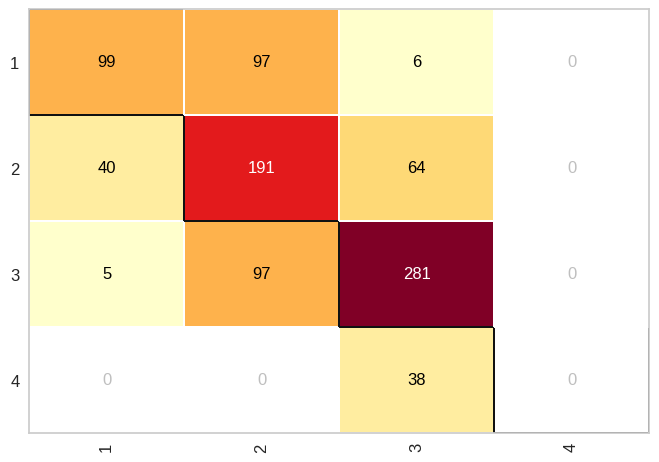

In [1435]:
cm = ConfusionMatrix(modelo)
cm.fit(X_treino, y_treino)
cm.score(X_teste, y_teste)

In [1438]:
importances = modelo.feature_importances_
feature_importance = pd.DataFrame({
    'Feature': X_treino.columns,
    'Importance': importances
}).sort_values('Importance', ascending=False)

print(feature_importance)

                                  Feature  Importance
4                                   Nível    0.831074
3                         Nivel_de_Ensino    0.079505
5                                  Python    0.039129
6   Tempo_de_experiencia_na_area_de_dados    0.037054
1                             PIB_2021_OR    0.008420
0                                    IDHM    0.004818
2                            Faixa_Etaria    0.000000
7                                   Uf_AL    0.000000
8                                   Uf_AM    0.000000
9                                   Uf_AP    0.000000
10                                  Uf_BA    0.000000
11                                  Uf_CE    0.000000
12                                  Uf_DF    0.000000
13                                  Uf_ES    0.000000
14                                  Uf_GO    0.000000
15                                  Uf_MA    0.000000
16                                  Uf_MG    0.000000
17                          

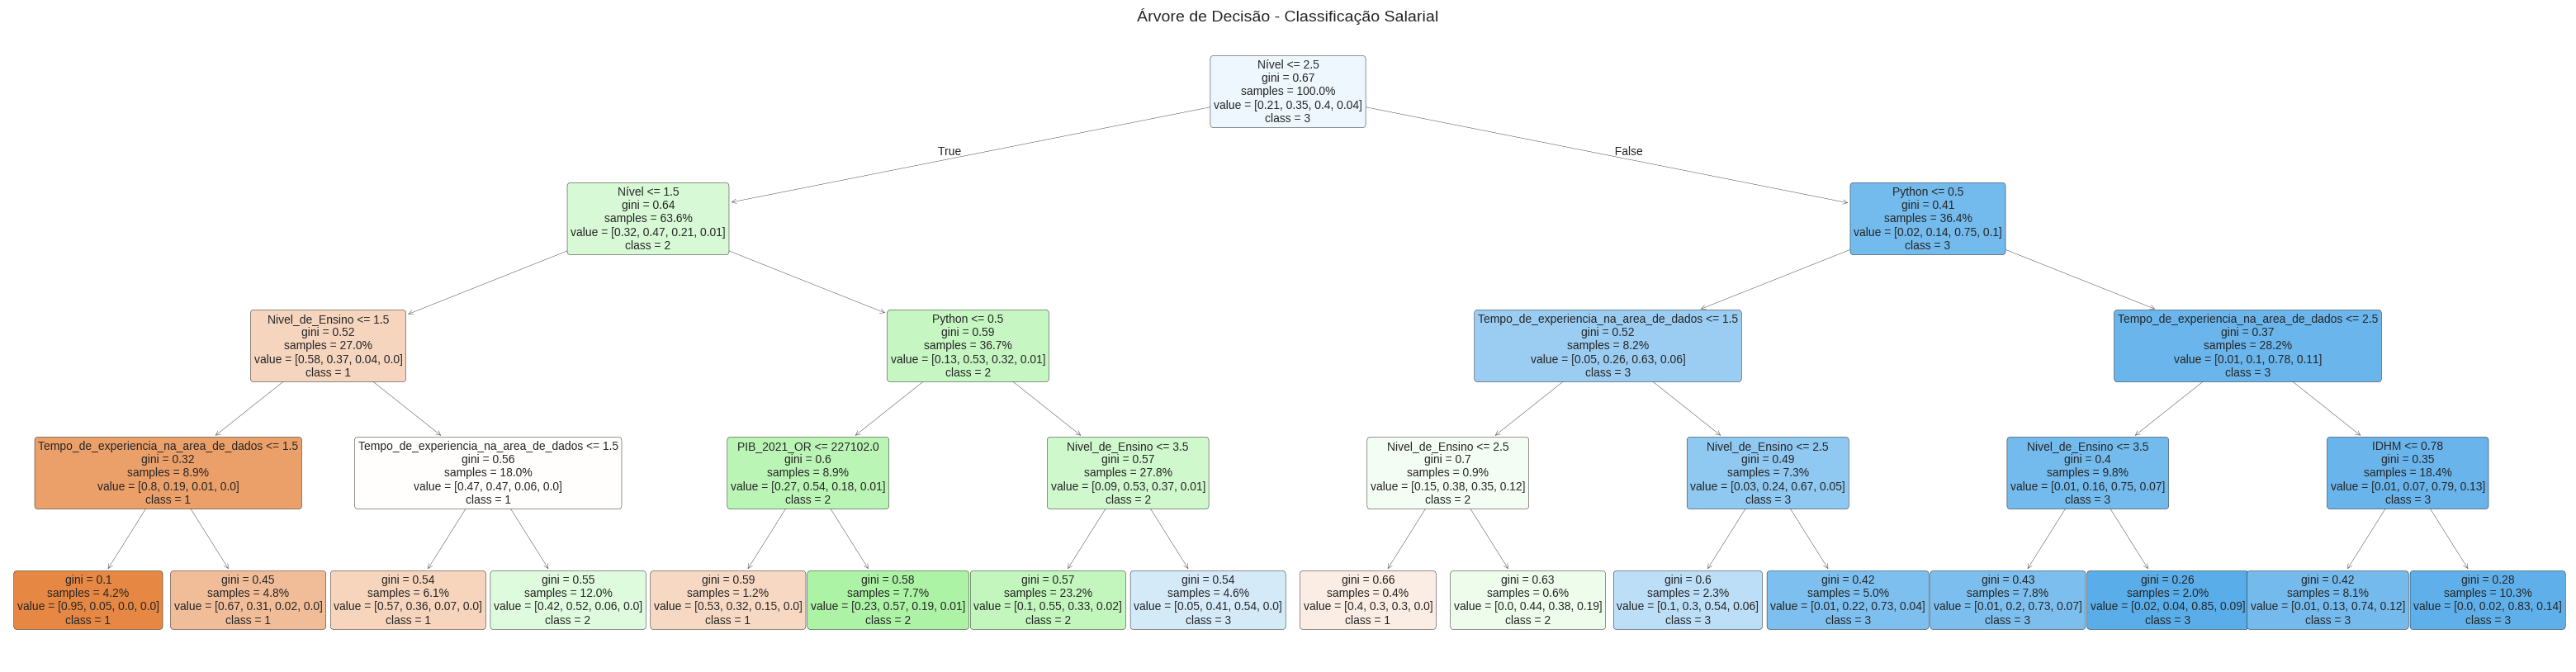

In [1449]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Configurações para uma visualização clara
plt.figure(figsize=(40,10))  # Ajuste o tamanho conforme necessário

# Plot da árvore com parâmetros otimizados
plot_tree(modelo,
          feature_names=X_treino.columns.tolist(),  # Nomes das features
          class_names=['1', '2', '3', '4'],         # Nomes das classes
          filled=True,                              # Preenchimento de cores
          rounded=True,                             # Bordas arredondadas
          proportion=True,                          # Mostra proporções
          precision=2,                              # Casas decimais
          fontsize=10)                              # Tamanho da fonte

plt.title("Árvore de Decisão - Classificação Salarial", fontsize=14)
plt.show()